# Systematic Mapping Review classification

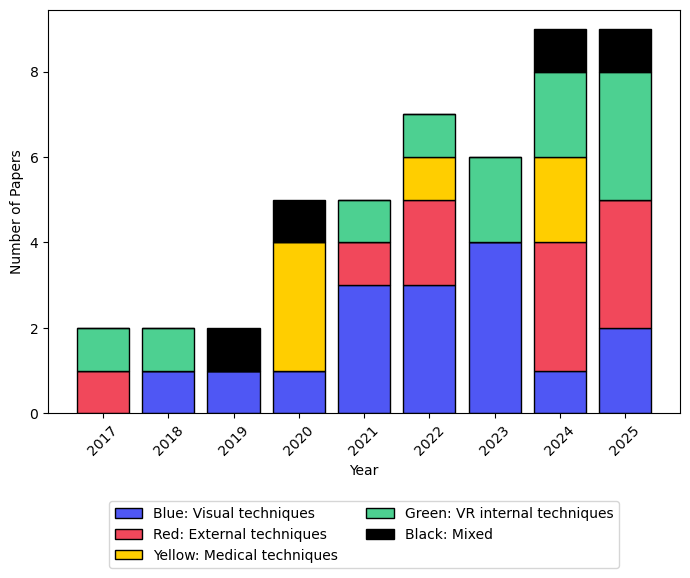

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Load and clean the CSV
# -----------------------------
df = pd.read_csv("Final Selection.csv", engine="python")
df.columns = df.columns.str.strip()

df = df[["Year", "Mitigation technique"]].copy()

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Mitigation technique"] = df["Mitigation technique"].astype(str).str.strip()

df = df.dropna(subset=["Year", "Mitigation technique"])
df["Year"] = df["Year"].astype(int)

# -----------------------------
# Normalize technique names
# -----------------------------
def normalize_technique(tech):
    tech = str(tech).strip()

    replacements = {
        "Visual Blurring": "Visual-Blurring",
        "Visual-Reference": "Visual-References",
        "Visual Reference": "Visual-References",
        "Visual References": "Visual-References",
        "FOV Restriction": "FOV-Restriction",
        "Adaptation Training": "Adaptation-Training",
        "Motion Synchronization": "Motion-Synchronization",
        "Haptic Feedback": "Haptic-Feedback",
        "Electrical Stimulation": "Electrical-Stimulation",
        "Pharmacological Intervention": "Pharmacological-Intervention",
        "Pharmacologicall-Intervention": "Pharmacological-Intervention",
        "Physical Therapy": "Physical-Therapy",
        "Multisensory Integration": "Multisensory-Integration",
        "Predictive Information": "Predictive-Information",
        "Adaptive System": "Adaptive-Systems",
        "Adaptive-System": "Adaptive-Systems",
        "Presence Enhancement": "Presence-Enhancement",
        "Audio Feedback": "Audio-Feedback",
        "Environmental Modification": "Environmental-Modification",
    }

    return replacements.get(tech, tech)

df["Mitigation technique"] = df["Mitigation technique"].apply(normalize_technique)

# -----------------------------
# Define groups (NO gray)
# -----------------------------
blue_group = {"FOV-Restriction", "Visual-Blurring", "Visual-References"}
red_group = {"Adaptation-Training", "Motion-Synchronization", "Haptic-Feedback"}
yellow_group = {"Electrical-Stimulation", "Pharmacological-Intervention", "Physical-Therapy"}
green_group = {
    "Multisensory-Integration",
    "Predictive-Information",
    "Adaptive-Systems",
    "Presence-Enhancement",
    "Audio-Feedback",
    "Environmental-Modification",
}
black_group = {"MIXED"}

def get_category(tech):
    if tech in blue_group:
        return "blue"
    elif tech in red_group:
        return "red"
    elif tech in yellow_group:
        return "yellow"
    elif tech in green_group:
        return "green"
    elif tech in black_group:
        return "black"
    else:
        return None  # remove gray

df["Category"] = df["Mitigation technique"].apply(get_category)

# Remove rows not classified
df = df[df["Category"].notna()]

# -----------------------------
# Count per year and category
# -----------------------------
category_order = ["blue", "red", "yellow", "green", "black"]

counts = (
    df.groupby(["Year", "Category"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=category_order, fill_value=0)
      .sort_index()
)

# -----------------------------
# Custom colors
# -----------------------------
colors = {
    "blue": "#4F57F4",
    "red": "#F1485B",
    "yellow": "#FFCE00",
    "green": "#4DD091",
    "black": "#000000"
}

# -----------------------------
# Plot stacked bar chart
# -----------------------------
plt.figure(figsize=(7, 6))

bottom = pd.Series([0] * len(counts), index=counts.index)

for category in category_order:
    plt.bar(
        counts.index,
        counts[category],
        bottom=bottom,
        color=colors[category],
        edgecolor="black",
        label=category
    )
    bottom += counts[category]

plt.xlabel("Year")
plt.ylabel("Number of Papers")
#plt.title("Mitigation Technique Categories by Publication Year")
plt.xticks(counts.index, rotation=45)

# -----------------------------
# Legend BELOW the plot
# -----------------------------
legend_elements = [
    Patch(facecolor=colors["blue"], edgecolor="black", label="Blue: Visual techniques"),
    Patch(facecolor=colors["red"], edgecolor="black", label="Red: External techniques"),
    Patch(facecolor=colors["yellow"], edgecolor="black", label="Yellow: Medical techniques"),
    Patch(facecolor=colors["green"], edgecolor="black", label="Green: VR internal techniques"),
    Patch(facecolor=colors["black"], edgecolor="black", label="Black: Mixed"),
]

plt.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=2
)

plt.tight_layout()

# Save image
plt.savefig("papers_per_year.png", dpi=300, bbox_inches="tight")

plt.show()

In [7]:
import pandas as pd

# Load CSV
df = pd.read_csv("Final Selection.csv", engine="python")
df.columns = df.columns.str.strip()

# Keep relevant column
df = df[["Mitigation technique"]].copy()

# Clean values
df["Mitigation technique"] = df["Mitigation technique"].astype(str).str.strip()

# -----------------------------
# Normalize technique names
# -----------------------------
def normalize_technique(tech):
    tech = str(tech).strip()

    replacements = {
        "Visual Blurring": "Visual-Blurring",
        "Visual-Reference": "Visual-References",
        "Visual Reference": "Visual-References",
        "Visual References": "Visual-References",
        "FOV Restriction": "FOV-Restriction",
        "Adaptation Training": "Adaptation-Training",
        "Motion Synchronization": "Motion-Synchronization",
        "Haptic Feedback": "Haptic-Feedback",
        "Electrical Stimulation": "Electrical-Stimulation",
        "Pharmacological Intervention": "Pharmacological-Intervention",
        "Pharmacologicall-Intervention": "Pharmacological-Intervention",
        "Physical Therapy": "Physical-Therapy",
        "Multisensory Integration": "Multisensory-Integration",
        "Predictive Information": "Predictive-Information",
        "Adaptive System": "Adaptive-Systems",
        "Adaptive-System": "Adaptive-Systems",
        "Presence Enhancement": "Presence-Enhancement",
        "Audio Feedback": "Audio-Feedback",
        "Environmental Modification": "Environmental-Modification",
    }

    return replacements.get(tech, tech)

df["Mitigation technique"] = df["Mitigation technique"].apply(normalize_technique)

# Remove empty values
df = df[df["Mitigation technique"].notna()]

# -----------------------------
# Count techniques
# -----------------------------
tech_counts = df["Mitigation technique"].value_counts().sort_values(ascending=False)

# Print results
print(tech_counts)

Mitigation technique
Visual-References               7
Haptic-Feedback                 6
FOV-Restriction                 5
Environmental-Modification      5
Predictive-Information          4
Visual-Blurring                 4
MIXED                           4
Electrical-Stimulation          3
Motion-Synchronization          2
Adaptation-Training             2
Adaptive-Systems                2
Pharmacological-Intervention    2
Physical-Therapy                1
Name: count, dtype: int64
